In [1]:
# import libraries
import os
os.environ["OMP_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



In [3]:
#load Dataset
df = pd.read_csv("mall customer data.csv")
# first 5 rows
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
# Check missing values
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
# Select Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Display selected columns
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


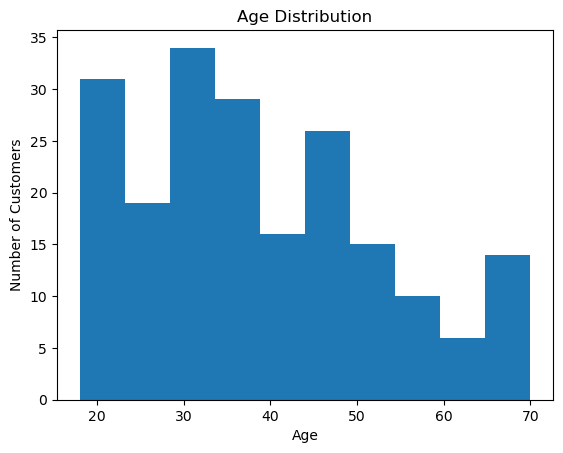

In [15]:
# histogram graph
plt.hist(df['Age'], bins=10)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")

plt.show()

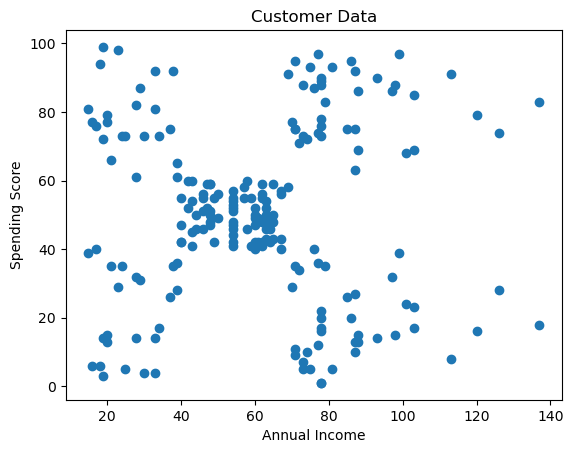

In [7]:
# Create scatter plot
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

# Add labels and title
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")

# Show graph
plt.show()

In [9]:
# Create empty list
wcss = []

# Run loop from 1 to 10
for i in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
        
    )
    # Train model
    kmeans.fit(X)

    # Store WCSS value
    wcss.append(kmeans.inertia_)

    

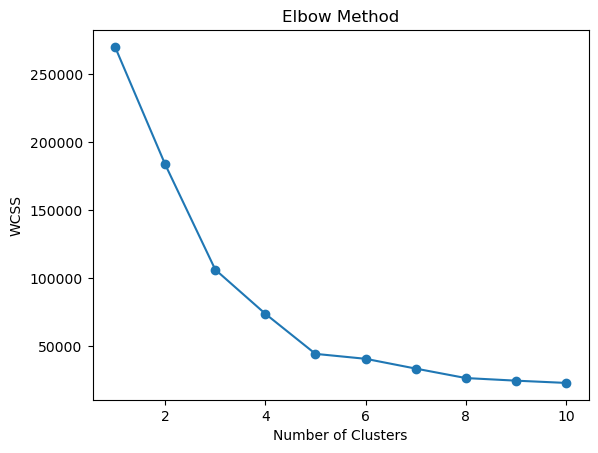

In [10]:
# Plot elbow graph
plt.plot(range(1, 11), wcss, marker='o')

# Add labels and title
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

# Show graph
plt.show()

In [11]:
# Create KMeans model
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

# Predict clusters
y_kmeans = kmeans.fit_predict(X)

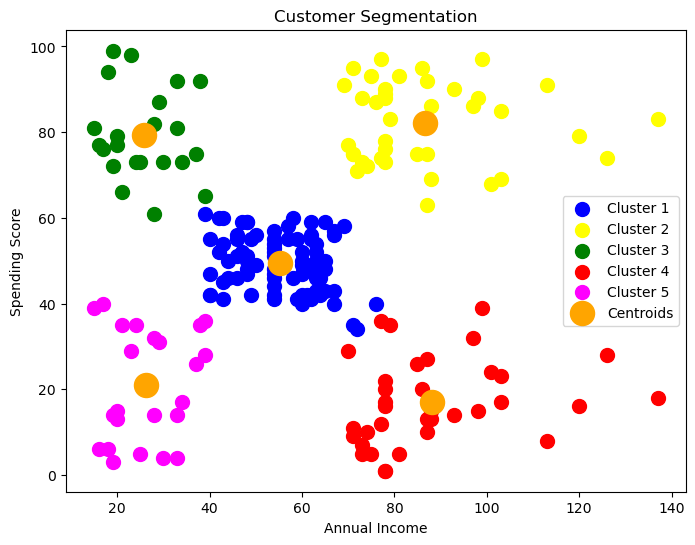

In [16]:
# Set graph size
plt.figure(figsize=(8, 6))


# Cluster 1
plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=100,
    c='blue',
    label='Cluster 1'
)

# Cluster 2
plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=100,
    c='yellow',
    label='Cluster 2'
)

# Cluster 3
plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=100,
    c='green',
    label='Cluster 3'
)

# Cluster 4
plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=100,
    c='red',
    label='Cluster 4'
)

# Cluster 5
plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=100,
    c='magenta',
    label='Cluster 5'
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='orange',
    label='Centroids'
)

# Add labels and title
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

# Show legend
plt.legend()

# Display graph
plt.show()

In [14]:
# Add cluster labels to dataset
df['Cluster'] = y_kmeans

# Display dataset
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
